# Predictive Analytics: Class Demo
### Stock Price Prediction (LSTM) · Sales Forecasting · Waiter Tips Regression · Deployment

This notebook walks through all four parts of the project:
1. Stock price prediction using an LSTM neural network
2. Sales forecasting and time-series analysis
3. Waiter tips prediction and regression refinement
4. Deploying a prediction pipeline

All data here is **synthetic**, generated for teaching purposes.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

import os

folder = '/content/drive/MyDrive/UIU_Project'

print(os.listdir(folder))

Mounted at /content/drive
['synthetic_predictive_analytics_dataset_1_5x.xlsx', 'synthetic_recommendation_system_dataset_1_5x.xlsx', 'Sentiment']


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Serif'

xl = pd.ExcelFile('/content/drive/MyDrive/UIU_Project/synthetic_predictive_analytics_dataset_1_5x.xlsx')
print(xl.sheet_names)

['Stock_Prices', 'Sales_Data', 'Waiter_Tips']


## Part 1 — Stock Price Prediction Using an LSTM Neural Network

An LSTM (Long Short-Term Memory) network is a type of recurrent neural network well suited to sequences, such as a stock's daily closing price. We will:
1. Take one ticker's closing prices
2. Scale them to [0, 1]
3. Build sliding windows (use the past 20 days to predict the next day)
4. Train a small LSTM and evaluate it on unseen, later dates

(1125, 7)


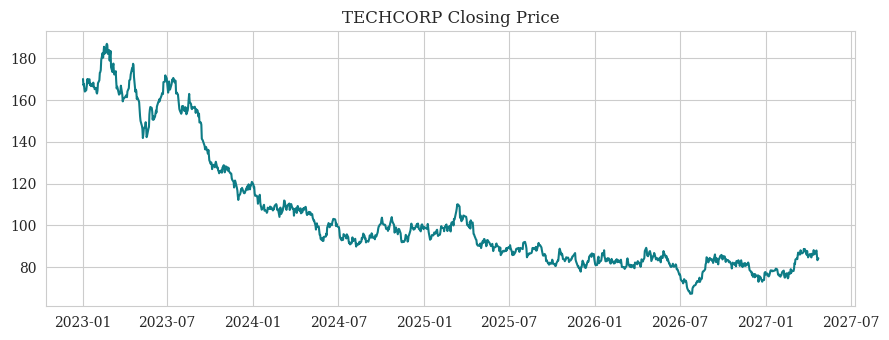

In [3]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

tf.random.set_seed(42)

stock = pd.read_excel('/content/drive/MyDrive/UIU_Project/synthetic_predictive_analytics_dataset_1_5x.xlsx', sheet_name='Stock_Prices', parse_dates=['date'])
techcorp = stock[stock['ticker']=='TECHCORP'].sort_values('date').reset_index(drop=True)
print(techcorp.shape)

plt.figure(figsize=(9,3.5))
plt.plot(techcorp['date'], techcorp['close'], color='#0E7C86')
plt.title('TECHCORP Closing Price')
plt.tight_layout(); plt.show()

In [4]:
prices = techcorp['close'].values.reshape(-1,1)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(prices)

WINDOW = 20
X, y = [], []
for i in range(WINDOW, len(scaled)):
    X.append(scaled[i-WINDOW:i, 0])
    y.append(scaled[i, 0])
X, y = np.array(X), np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)   # [samples, timesteps, features]

# Time-based split: train on the earlier ~80%, test on the later ~20% (never shuffle time series)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (884, 20, 1)  Test: (221, 20, 1)


In [5]:
model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, 1)),
    keras.layers.LSTM(32, return_sequences=False),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1),
])
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

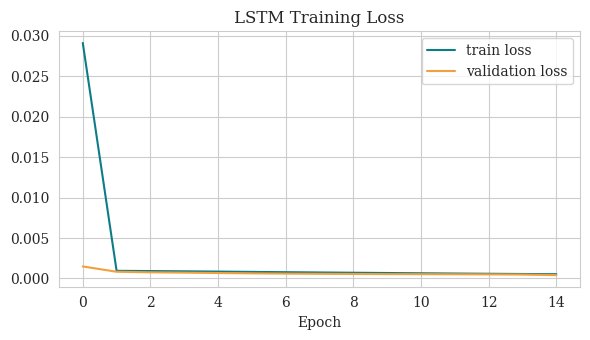

In [6]:
history = model.fit(X_train, y_train, epochs=15, batch_size=16,
                     validation_data=(X_test, y_test), verbose=0)

plt.figure(figsize=(6,3.5))
plt.plot(history.history['loss'], label='train loss', color='#0E7C86')
plt.plot(history.history['val_loss'], label='validation loss', color='#F2A03D')
plt.legend(); plt.title('LSTM Training Loss'); plt.xlabel('Epoch')
plt.tight_layout(); plt.show()

LSTM RMSE on held-out (later) test dates: $2.43


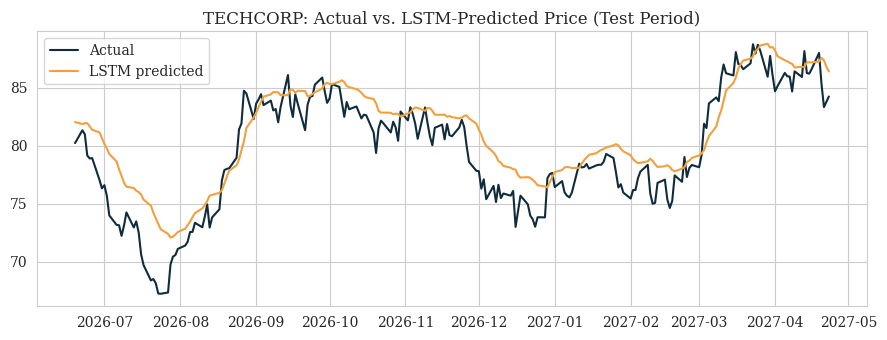

In [7]:
pred_scaled = model.predict(X_test, verbose=0)
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1,1))

rmse = mean_squared_error(actual, pred) ** 0.5
print(f"LSTM RMSE on held-out (later) test dates: ${rmse:.2f}")

test_dates = techcorp['date'].values[WINDOW+split:]
plt.figure(figsize=(9,3.5))
plt.plot(test_dates, actual, label='Actual', color='#0F2C3D')
plt.plot(test_dates, pred, label='LSTM predicted', color='#F2A03D')
plt.title('TECHCORP: Actual vs. LSTM-Predicted Price (Test Period)')
plt.legend(); plt.tight_layout(); plt.show()

**Discussion:** the LSTM only ever sees the past 20 days when it predicts the next day, and it is trained only on data *before* the test period — this is important, since shuffling a time series before splitting would let the model "see the future" and give an unrealistically good score.

## Part 2 — Sales Forecasting and Time-Series Analysis

Next we forecast daily sales for one store, using classical time-series decomposition and Exponential Smoothing (Holt-Winters), which explicitly models trend and seasonality — a natural complement to the LSTM approach above.

(1095,)


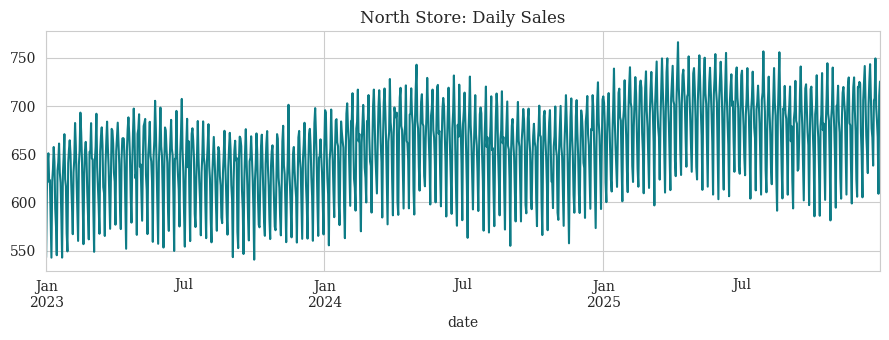

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sales = pd.read_excel('/content/drive/MyDrive/UIU_Project/synthetic_predictive_analytics_dataset_1_5x.xlsx', sheet_name='Sales_Data', parse_dates=['date'])
north = sales[sales['store']=='North'].sort_values('date').set_index('date')['sales']
print(north.shape)
north.plot(figsize=(9,3.5), color='#0E7C86', title='North Store: Daily Sales')
plt.tight_layout(); plt.show()

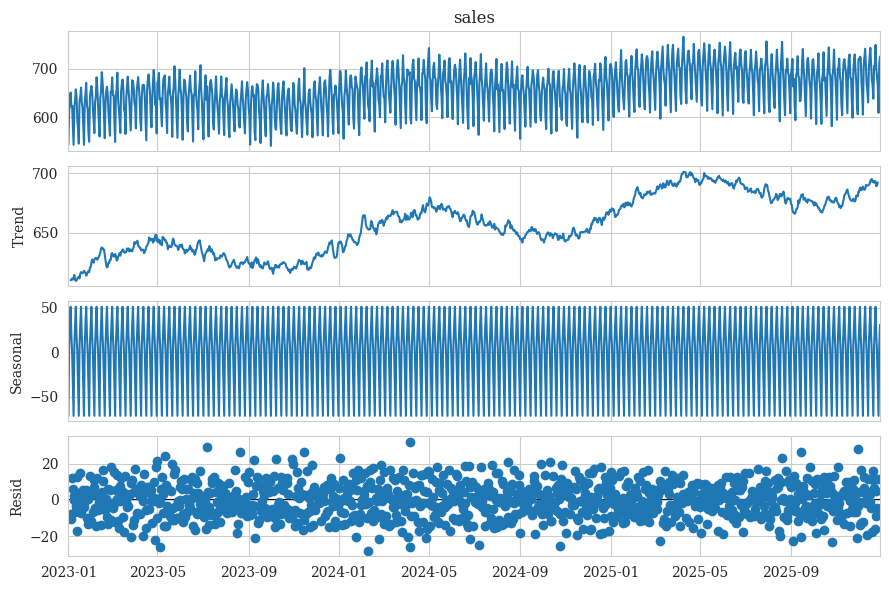

In [9]:
decomp = seasonal_decompose(north, model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(9,6)
plt.tight_layout(); plt.show()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Holt-Winters RMSE on held-out 60 days: 14.1 units/day


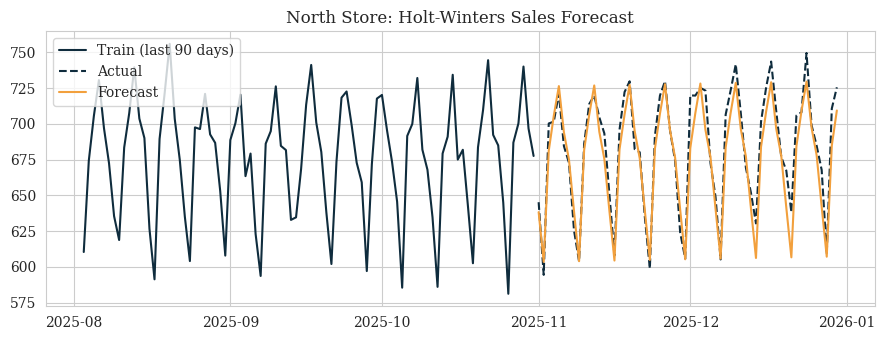

In [10]:
# Time-based split: last 60 days as the test period
train, test = north[:-60], north[-60:]

hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7).fit()
forecast = hw_model.forecast(len(test))

rmse_hw = mean_squared_error(test, forecast) ** 0.5
print(f"Holt-Winters RMSE on held-out 60 days: {rmse_hw:.1f} units/day")

plt.figure(figsize=(9,3.5))
plt.plot(train[-90:], label='Train (last 90 days)', color='#0F2C3D')
plt.plot(test, label='Actual', color='#0F2C3D', linestyle='--')
plt.plot(test.index, forecast, label='Forecast', color='#F2A03D')
plt.title('North Store: Holt-Winters Sales Forecast')
plt.legend(); plt.tight_layout(); plt.show()

## Part 3 — Waiter Tips Prediction and Regression Refinement

Now a simpler, tabular regression problem: predict the tip amount from bill size and visit details. We start with a plain baseline model, then refine it and check whether refinement actually helps.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

tips = pd.read_excel('/content/drive/MyDrive/UIU_Project/synthetic_predictive_analytics_dataset_1_5x.xlsx', sheet_name='Waiter_Tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,26.06,4.15,Female,Yes,Fri,Lunch,2
1,20.46,2.86,Female,No,Sat,Lunch,3
2,30.98,5.42,Male,No,Thur,Lunch,4
3,16.25,1.51,Male,No,Thur,Lunch,4
4,19.78,2.36,Male,No,Fri,Dinner,2


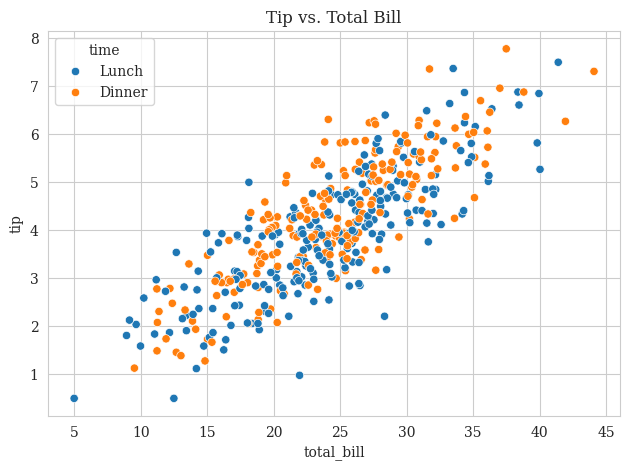

Correlation between total_bill and tip: 0.814


In [12]:
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time')
plt.title('Tip vs. Total Bill')
plt.tight_layout(); plt.show()

print("Correlation between total_bill and tip:", round(tips['total_bill'].corr(tips['tip']), 3))

In [13]:
X = tips.drop(columns='tip')
y = tips['tip']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_cols = ['sex','smoker','day','time']
num_cols = ['total_bill','size']

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_cols),
    ('num', StandardScaler(), num_cols),
])

# Baseline: total_bill only, plain linear regression
baseline = LinearRegression()
baseline.fit(X_train[['total_bill']], y_train)
baseline_pred = baseline.predict(X_test[['total_bill']])
baseline_r2 = r2_score(y_test, baseline_pred)
print(f"Baseline (total_bill only) R²: {baseline_r2:.3f}")

Baseline (total_bill only) R²: 0.602


In [14]:
# Refinement 1: full feature set + linear regression, in a proper preprocessing pipeline
linreg_pipe = Pipeline([('prep', preprocess), ('model', LinearRegression())])
linreg_pipe.fit(X_train, y_train)
linreg_pred = linreg_pipe.predict(X_test)
linreg_r2 = r2_score(y_test, linreg_pred)
print(f"Refined linear regression (all features) R²: {linreg_r2:.3f}")

# Refinement 2: Ridge regression (regularized) on the same features
ridge_pipe = Pipeline([('prep', preprocess), ('model', Ridge(alpha=1.0))])
ridge_pipe.fit(X_train, y_train)
ridge_pred = ridge_pipe.predict(X_test)
ridge_r2 = r2_score(y_test, ridge_pred)
print(f"Ridge regression (all features) R²: {ridge_r2:.3f}")

# Refinement 3: Random Forest, to check whether a non-linear model helps
rf_pipe = Pipeline([('prep', preprocess), ('model', RandomForestRegressor(n_estimators=200, random_state=42))])
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
print(f"Random Forest (all features) R²: {rf_r2:.3f}")

Refined linear regression (all features) R²: 0.620
Ridge regression (all features) R²: 0.620
Random Forest (all features) R²: 0.536


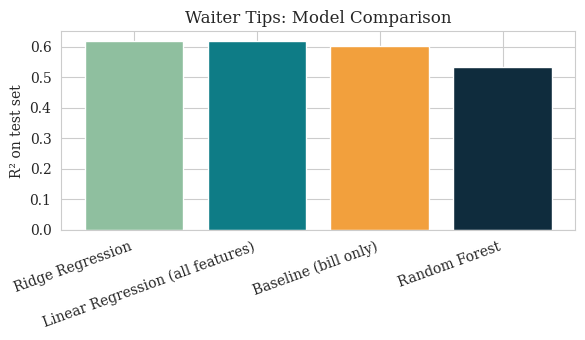

,Model,R2
0,Ridge Regression,0.620350
1,Linear Regression (all features),0.620043
2,Baseline (bill only),0.602358
3,Random Forest,0.535779


In [15]:
comparison = pd.DataFrame({
    "Model": ["Baseline (bill only)", "Linear Regression (all features)", "Ridge Regression", "Random Forest"],
    "R2": [baseline_r2, linreg_r2, ridge_r2, rf_r2],
})
comparison = comparison.sort_values("R2", ascending=False).reset_index(drop=True)

plt.figure(figsize=(6,3.5))
plt.bar(comparison['Model'], comparison['R2'], color=['#8FBF9F','#0E7C86','#F2A03D','#0F2C3D'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('R² on test set')
plt.title('Waiter Tips: Model Comparison')
plt.tight_layout(); plt.show()
comparison

**Discussion:** adding day, time, and party size on top of total_bill usually improves R² only modestly, since total_bill alone already captures most of the signal (larger bills mean larger tips). This is a useful, realistic result to discuss: refinement does not always produce a dramatically better model, and knowing *why* is part of the analysis.

## Part 4 — Deploying a Prediction Pipeline

A trained model is only useful if it can be reused without retraining. We save the entire preprocessing + model pipeline as a single file, then show how another program (e.g. a web service) would load it and make predictions on brand-new data.

In [16]:
import joblib

joblib.dump(rf_pipe, 'tips_pipeline.joblib')
print("Pipeline saved to tips_pipeline.joblib")

# Simulate a completely separate process loading the saved pipeline
loaded_pipe = joblib.load('tips_pipeline.joblib')

new_bills = pd.DataFrame([
    {"total_bill": 45.00, "sex": "Male", "smoker": "No", "day": "Sat", "time": "Dinner", "size": 4},
    {"total_bill": 18.50, "sex": "Female", "smoker": "Yes", "day": "Thur", "time": "Lunch", "size": 2},
])
predicted_tips = loaded_pipe.predict(new_bills)
new_bills['predicted_tip'] = predicted_tips.round(2)
new_bills

Pipeline saved to tips_pipeline.joblib


,total_bill,sex,smoker,day,time,size,predicted_tip
0,45.0,Male,No,Sat,Dinner,4,6.95
1,18.5,Female,Yes,Thur,Lunch,2,2.58


In a real deployment, this same `joblib.load(...)` — `pipeline.predict(...)` pattern sits behind a web API. A minimal example using FastAPI is shown below as reference code (not executed in this notebook, since it needs a running server):

```python
# app.py — a minimal prediction API (illustrative, not run here)
from fastapi import FastAPI
import joblib, pandas as pd

app = FastAPI()
pipe = joblib.load("tips_pipeline.joblib")

@app.post("/predict")
def predict(total_bill: float, sex: str, smoker: str, day: str, time: str, size: int):
    row = pd.DataFrame([{
        "total_bill": total_bill, "sex": sex, "smoker": smoker,
        "day": day, "time": time, "size": size,
    }])
    return {"predicted_tip": float(pipe.predict(row)[0])}

# Run with:  uvicorn app:app --reload
```

The LSTM and Holt-Winters models from Parts 1–2 can be deployed the same way: save the fitted model (and, for the LSTM, the `MinMaxScaler`) and wrap `model.predict(...)` in an endpoint or a scheduled batch job that runs each morning.

## Discussion prompts for class

- Why must the stock and sales train/test splits be done **by date**, rather than a random shuffle? What would go wrong if you shuffled first?
- The LSTM only used closing price. What other features (volume, moving averages, other tickers) might improve it, and why?
- For the waiter tips model, is R² alone enough to choose a "best" model? What would you also want to check (e.g. overfitting, interpretability, prediction speed)?
- Why does a saved pipeline (preprocessing + model together) matter for deployment, compared to saving only the trained model?

These are exactly the kinds of questions your **Evaluation and Model Comparison** and **Result Interpretation and Report** deliverables ask you to answer.